# Air Quality Analytics Report

This notebook reports on the curated HDFS JSONL dataset for Sofia. The Spark batch logic lives in `src/analytics/` and this notebook only loads the shared results, summarizes them, and visualizes them.

## Project Goal and Source

Analyze curated AQICN records stored in HDFS and report the main trends for AQI, pollutants, weather correlation, and spike events.

Curated source path:

`hdfs://namenode:9000/data/air-quality/sofia/curated/*.jsonl`

In [1]:
from matplotlib import pyplot as plt

from src.analytics.batch_analysis import DEFAULT_CITY
from src.analytics.batch_analysis import DEFAULT_HDFS_ROOT
from src.analytics.batch_analysis import create_spark_session
from src.analytics.batch_analysis import run_batch_analysis
from src.analytics.batch_analysis import to_pandas_table

plt.style.use("seaborn-v0_8-whitegrid")

spark = create_spark_session("air-quality-analytics-notebook")
results = run_batch_analysis(spark, DEFAULT_HDFS_ROOT, DEFAULT_CITY)
results.keys()

dict_keys(['normalized', 'hourly_aqi', 'average_pollutants', 'dominant_pollutants', 'weather_correlations', 'aqi_spikes'])

## Dataset Preview and Schema Check

In [2]:
normalized = results["normalized"]
normalized.printSchema()
normalized.select(
    "timestamp",
    "event_timestamp",
    "day",
    "hour",
    "aqi",
    "dominant_pollutant",
).show(5, truncate=False)

root
 |-- timestamp: string (nullable = true)
 |-- station_id: integer (nullable = true)
 |-- station_name: string (nullable = true)
 |-- latitude: double (nullable = true)
 |-- longitude: double (nullable = true)
 |-- aqi: integer (nullable = true)
 |-- dominant_pollutant: string (nullable = true)
 |-- pm10: double (nullable = true)
 |-- no2: double (nullable = true)
 |-- o3: double (nullable = true)
 |-- temperature: double (nullable = true)
 |-- humidity: double (nullable = true)
 |-- wind: double (nullable = true)
 |-- pressure: double (nullable = true)
 |-- dew: double (nullable = true)
 |-- event_timestamp: timestamp (nullable = true)
 |-- day: string (nullable = true)
 |-- hour: integer (nullable = true)

+-------------------------+-------------------+----------+----+---+------------------+
|timestamp                |event_timestamp    |day       |hour|aqi|dominant_pollutant|
+-------------------------+-------------------+----------+----+---+------------------+
|2026-04-08T15:00

## Hourly AQI

In [3]:
hourly_pdf = to_pandas_table(results["hourly_aqi"])
hourly_pdf

,hour,avg_aqi
0,12,40.555556
1,13,42.000000


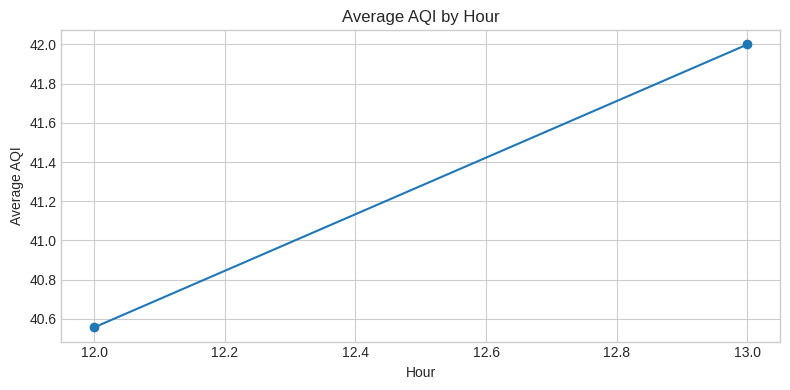

In [4]:
ax = hourly_pdf.plot(kind="line", x="hour", y="avg_aqi", marker="o", legend=False, figsize=(8, 4))
ax.set_title("Average AQI by Hour")
ax.set_xlabel("Hour")
ax.set_ylabel("Average AQI")
plt.tight_layout()
plt.show()

## Pollutant Averages

In [5]:
pollutants_pdf = to_pandas_table(results["average_pollutants"])
pollutants_pdf

,avg_pm10,avg_no2,avg_o3
0,15.692308,4.9,40.946154


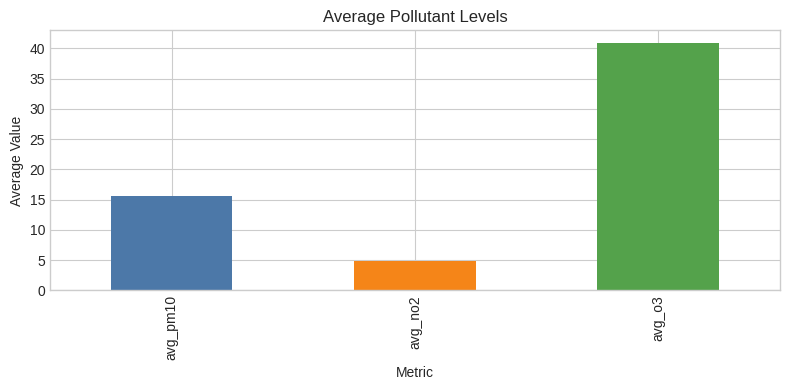

In [6]:
pollutant_values = pollutants_pdf.iloc[0][["avg_pm10", "avg_no2", "avg_o3"]]
ax = pollutant_values.plot(kind="bar", figsize=(8, 4), color=["#4c78a8", "#f58518", "#54a24b"])
ax.set_title("Average Pollutant Levels")
ax.set_xlabel("Metric")
ax.set_ylabel("Average Value")
plt.tight_layout()
plt.show()

## Dominant Pollutants

In [7]:
dominant_pdf = to_pandas_table(results["dominant_pollutants"])
dominant_pdf

,dominant_pollutant,count
0,o3,13


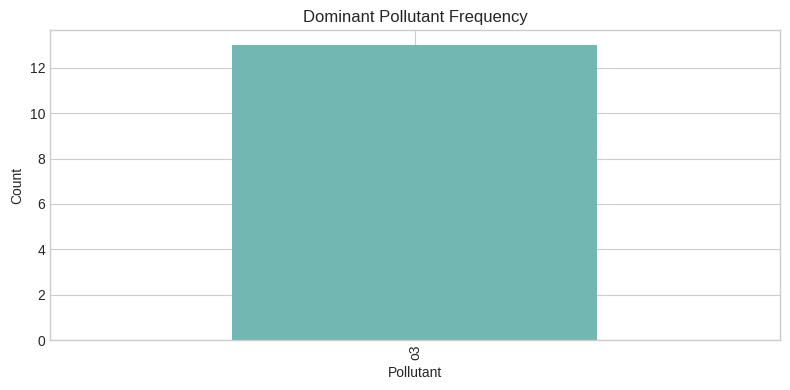

In [8]:
ax = dominant_pdf.plot(kind="bar", x="dominant_pollutant", y="count", legend=False, figsize=(8, 4), color="#72b7b2")
ax.set_title("Dominant Pollutant Frequency")
ax.set_xlabel("Pollutant")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

## Weather Correlations

In [9]:
correlations_pdf = to_pandas_table(results["weather_correlations"])
correlations_pdf

,aqi_temperature_corr,aqi_humidity_corr,aqi_wind_corr
0,0.802225,-0.849837,-5.370543e-16


## AQI Spikes

In [10]:
spikes_pdf = to_pandas_table(results["aqi_spikes"])
spikes_pdf[["station_id", "event_timestamp", "aqi", "previous_aqi", "aqi_jump", "is_threshold_spike", "is_jump_spike"]]

,station_id,event_timestamp,aqi,previous_aqi,aqi_jump,is_threshold_spike,is_jump_spike


## Final Conclusions

Use the tables above to summarize the Sofia air quality pattern in plain language:

- Which hour has the highest average AQI?
- Which pollutant is dominant most often?
- How strong are the AQI correlations with temperature, humidity, and wind?
- Which spikes need the most attention?

When finished, stop the Spark session if you do not need it anymore:

```python
spark.stop()
```